<a href="https://colab.research.google.com/github/marygizem/-Machine-Learning-and-Predictive-Analytics/blob/main/Updated_Milestone_2_Project_Forecasting_Model_with_DataViz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forecasting Model (Week 7)

This notebook develops a sales forecasting model using historical transaction data. It includes feature engineering, visualization, model comparison, and forecasting for the next three months.

In [ ]:
from google.colab import files
files.upload()

Saving merged_data.csv to merged_data.csv


{'merged_data.csv': b'Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price_x,Total_Cost,Company_Name,Company_Profit,Address,Product_Name,Product_Price_y\n2.0,29.0,19.0,16.0,2021-02-21,97930.9933803618,1428000.0,Sky  Industries  29,61952.0,"Edsa, brgy. 606, makati, philippines!",EcoNomix Modeler,"?95,200"\n5.0,47.0,3.0,8.0,2021-02-21,99575.60963363378,705600.0,Green  Industries  47,31130.0,"Taft Ave, Barangay 707, Mandaluyong, Philippines",TrendWise Forecaster,"?100,800"\n6.0,80.0,11.0,4.0,2021-07-12,160658.67535045007,627200.0,Green  Partners  80,111227.0,"Commonwealth Ave, Barangay 202, Manila, Philippines",OptiFlow Automation,"?156,800"\n8.0,21.0,20.0,7.0,2021-02-21,229217.9414680993,1792000.0,Dynamic Enterprises 21,,"Ortigas Ave, Barangay 707, Davao City, Philippines",FinSphere Intelligence Suite,"?224,000"\n10.0,3.0,20.0,6.0,2021-02-21,238293.8513034097,1120000.0,Quantum Associates 3,110664.0,"Roxas Blvd, Barangay 505, Pasig, Philippines",FinSphere Intellige

In [ ]:
import os
print(os.listdir())

['.config', 'merged_data.csv', 'sample_data']


In [ ]:
import pandas as pd

merged_data = pd.read_csv("merged_data.csv")
print(merged_data.head())

   Transaction_ID  Company_ID  Product_ID  Quantity Transaction_Date  \
0             2.0        29.0        19.0      16.0       2021-02-21   
1             5.0        47.0         3.0       8.0       2021-02-21   
2             6.0        80.0        11.0       4.0       2021-07-12   
3             8.0        21.0        20.0       7.0       2021-02-21   
4            10.0         3.0        20.0       6.0       2021-02-21   

   Product_Price_x  Total_Cost            Company_Name  Company_Profit  \
0     97930.993380   1428000.0     Sky  Industries  29         61952.0   
1     99575.609634    705600.0   Green  Industries  47         31130.0   
2    160658.675350    627200.0     Green  Partners  80        111227.0   
3    229217.941468   1792000.0  Dynamic Enterprises 21             NaN   
4    238293.851303   1120000.0    Quantum Associates 3        110664.0   

                                             Address  \
0              Edsa, brgy. 606, makati, philippines!   
1   Taft A

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# convert date column
merged_data["Transaction_Date"] = pd.to_datetime(merged_data["Transaction_Date"], errors="coerce")

# remove rows with invalid dates
merged_data = merged_data.dropna(subset=["Transaction_Date"])

# create monthly period
merged_data["YearMonth"] = merged_data["Transaction_Date"].dt.to_period("M")

print(merged_data[["Transaction_Date", "YearMonth"]].head())

  Transaction_Date YearMonth
0       2021-02-21   2021-02
1       2021-02-21   2021-02
2       2021-07-12   2021-07
3       2021-02-21   2021-02
4       2021-02-21   2021-02


## Monthly Sales Aggregation

This section aggregates the historical transaction data into monthly sales so the dataset can be used for forecasting.

In [ ]:
monthly_sales = merged_data.groupby("YearMonth").agg(
    total_sales=("Total_Cost", "sum"),
    total_quantity=("Quantity", "sum"),
    avg_price=("Product_Price_x", "mean"),
    transaction_count=("Transaction_ID", "count")
).reset_index()

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

print(monthly_sales.head())
print(monthly_sales.shape)

  YearMonth   total_sales  total_quantity      avg_price  transaction_count
0   2020-10  4.849600e+06            32.0  148327.692927                  3
1   2020-11  4.777360e+07           368.0  136653.572830                 33
2   2020-12  2.880640e+07           204.0  136438.763122                 21
3   2021-01  4.709600e+07           347.0  137383.563346                 35
4   2021-02  5.694074e+09         41954.0  135119.607704               3999
(49, 5)


##Visualization

This chart shows the monthly sales pattern over time and helps identify overall trends in the data. The dataset was transformed into a time-series format by aggregating sales monthly. This allows the model to capture trends, seasonality, and patterns over time.

Time-based features and lag variables were created to simulate time-series forecasting behavior, where past values influence future predictions.

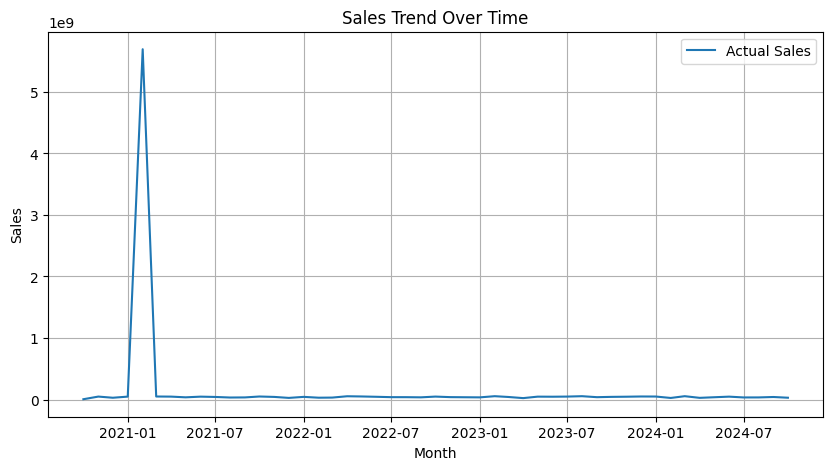

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["total_sales"], label="Actual Sales")
plt.title("Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Feature Engineering

This section creates new forecasting features such as month, quarter, lag values, and rolling averages to help improve prediction accuracy.

In [ ]:
monthly_sales["YearMonth"] = pd.to_datetime(monthly_sales["YearMonth"])

# time-based features
monthly_sales["month"] = monthly_sales["YearMonth"].dt.month
monthly_sales["quarter"] = monthly_sales["YearMonth"].dt.quarter

# lag features
monthly_sales["lag_1"] = monthly_sales["total_sales"].shift(1)
monthly_sales["lag_2"] = monthly_sales["total_sales"].shift(2)
monthly_sales["lag_3"] = monthly_sales["total_sales"].shift(3)

# rolling feature
monthly_sales["rolling_3"] = monthly_sales["total_sales"].rolling(3).mean()

# drop rows with null values created by lag/rolling operations
monthly_sales = monthly_sales.dropna().reset_index(drop=True)

print(monthly_sales.head())
print(monthly_sales.shape)

   YearMonth   total_sales  total_quantity      avg_price  transaction_count  \
0 2021-01-01  4.709600e+07           347.0  137383.563346                 35   
1 2021-02-01  5.694074e+09         41954.0  135119.607704               3999   
2 2021-03-01  4.901680e+07           385.0  126132.230470                 37   
3 2021-04-01  4.713520e+07           370.0  126509.331814                 32   
4 2021-05-01  3.565520e+07           278.0  128247.636309                 27   

   month  quarter         lag_1         lag_2         lag_3     rolling_3  
0      1        1  2.880640e+07  4.777360e+07  4.849600e+06  4.122533e+07  
1      2        1  4.709600e+07  2.880640e+07  4.777360e+07  1.923326e+09  
2      3        1  5.694074e+09  4.709600e+07  2.880640e+07  1.930062e+09  
3      4        2  4.901680e+07  5.694074e+09  4.709600e+07  1.930075e+09  
4      5        2  4.713520e+07  4.901680e+07  5.694074e+09  4.393573e+07  
(46, 11)


## Correlation Analysis

This heatmap helps assess the relationship between engineered features and total sales.

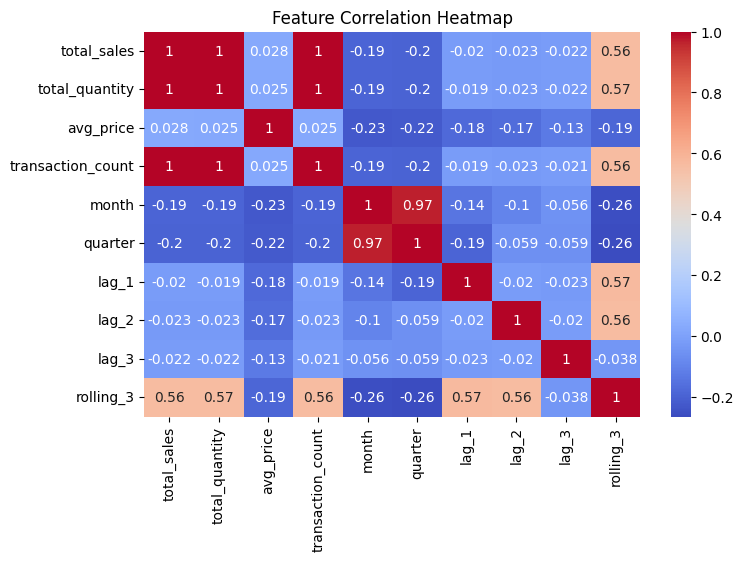

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(monthly_sales.drop(columns=["YearMonth"]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## ARIMA and SARIMA Models

ARIMA was used as a baseline time-series model to capture trends in the sales data. SARIMA was implemented to account for seasonal patterns in monthly sales.

These models rely on historical values and trends to generate forecasts without requiring additional feature engineering. SARIMA improves forecasting by incorporating both trend and seasonality, making it suitable for business data with recurring patterns.
An ARIMA model was also tested as a traditional time-series forecasting method. This model uses past values and trends to generate future predictions without requiring feature engineering.

Comparing machine learning models and ARIMA provides a broader evaluation of forecasting approaches.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ARIMA
arima_model = ARIMA(monthly_sales["total_sales"], order=(1,1,1))
arima_fit = arima_model.fit()
forecast_arima = arima_fit.forecast(steps=6)

print("ARIMA Forecast:")
print(forecast_arima)

# SARIMA (using SARIMAX)
sarima_model = SARIMAX(
    monthly_sales["total_sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)
sarima_fit = sarima_model.fit(disp=False)
forecast_sarima = sarima_fit.forecast(steps=6)

print("\nSARIMA Forecast:")
print(forecast_sarima)

ARIMA Forecast:
49    1.542116e+08
50    1.523295e+08
51    1.523578e+08
52    1.523574e+08
53    1.523574e+08
54    1.523574e+08
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'



SARIMA Forecast:
49   -5.162236e+07
50   -6.624138e+07
51   -6.075265e+07
52    1.033803e+09
53   -6.022158e+07
54   -6.586568e+07
Name: predicted_mean, dtype: float64


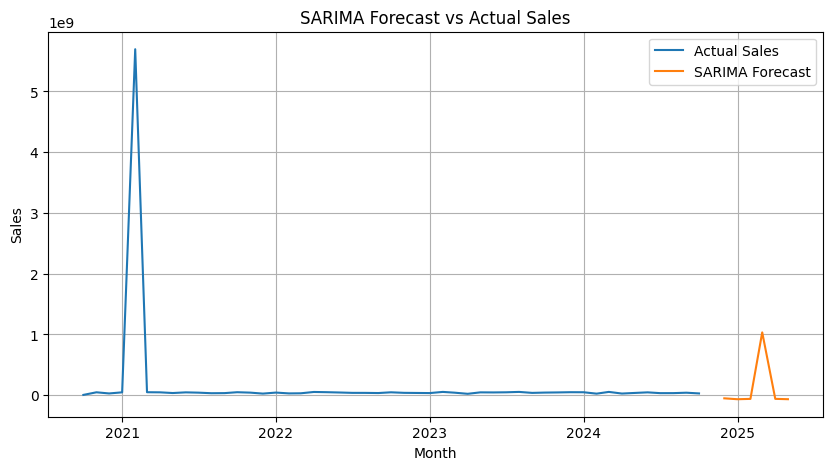

In [ ]:
plt.figure(figsize=(10,5))

# actual data
plt.plot(monthly_sales["YearMonth"], monthly_sales["total_sales"], label="Actual Sales")

# future dates
future_dates = pd.date_range(
    start=monthly_sales["YearMonth"].iloc[-1],
    periods=7,
    freq="ME"
)[1:]

# SARIMA forecast
plt.plot(future_dates, forecast_sarima, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Model Comparison

This section develops two forecasting models, Linear Regression and Random Forest, and compares their results using error metrics.

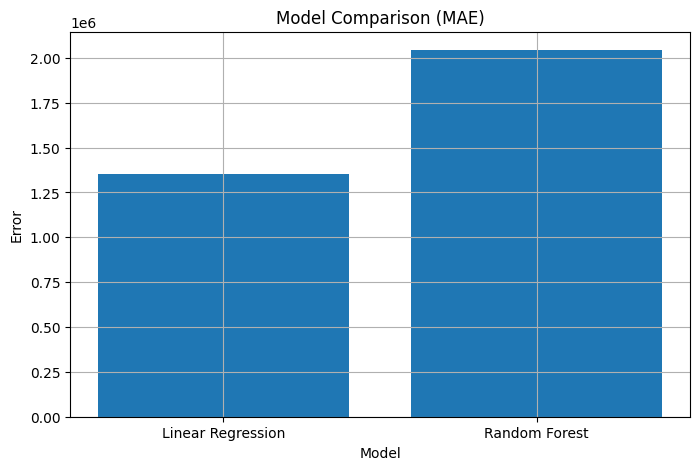

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(comparison_m2["Model"], comparison_m2["MAE"])
plt.title("Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("Error")
plt.grid(True)
plt.show()

In [ ]:
# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 2044093.3333333333
Random Forest RMSE: 2735112.750492991


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

print(comparison)

               Model           MAE          RMSE
0  Linear Regression  1.351750e+06  1.499341e+06
1      Random Forest  2.044093e+06  2.735113e+06


## Forecasting Results

This section presents the actual sales values and the forecasted values for the test period.

In [ ]:
results = pd.DataFrame({
    "Month": test["YearMonth"].astype(str).values,
    "Actual_Sales": y_test.values,
    "LR_Forecast": lr_pred,
    "RF_Forecast": rf_pred
})

print(results)

        Month  Actual_Sales   LR_Forecast  RF_Forecast
0  2024-05-01    36971200.0  3.922224e+07   38010840.0
1  2024-06-01    46737600.0  4.638229e+07   46929064.0
2  2024-07-01    33751200.0  3.183926e+07   29684592.0
3  2024-08-01    34092800.0  3.336872e+07   35997528.0
4  2024-09-01    40952800.0  3.954881e+07   40744424.0
5  2024-10-01    29131200.0  2.766705e+07   33984944.0


In [ ]:
print(monthly_sales.dtypes)

YearMonth            datetime64[ns]
total_sales                 float64
total_quantity              float64
avg_price                   float64
transaction_count             int64
year                          int32
rolling_6                   float64
lag_1                       float64
lag_2                       float64
lag_3                       float64
dtype: object


In [ ]:
# =========================
# FORECAST NEXT 3 MONTHS
# =========================

future_predictions = []
last_data = monthly_sales_refined.copy()

for i in range(3):
    next_month = last_data["YearMonth"].iloc[-1] + pd.DateOffset(months=1)

    future_row = {}
    future_row["YearMonth"] = next_month
    future_row["month"] = next_month.month
    future_row["quarter"] = next_month.quarter
    future_row["year"] = next_month.year

    future_row["lag_1"] = last_data["total_sales"].iloc[-1]
    future_row["lag_2"] = last_data["total_sales"].iloc[-2]
    future_row["lag_3"] = last_data["total_sales"].iloc[-3]

    future_row["rolling_3"] = last_data["total_sales"].iloc[-3:].mean()
    future_row["rolling_6"] = last_data["total_sales"].iloc[-6:].mean()

    future_row["total_quantity"] = last_data["total_quantity"].iloc[-3:].mean()
    future_row["avg_price"] = last_data["avg_price"].iloc[-3:].mean()
    future_row["transaction_count"] = last_data["transaction_count"].iloc[-3:].mean()

    future_df_row = pd.DataFrame([future_row])

    # make sure columns match training data exactly
    X_future = future_df_row[X_train.columns]

    pred = rf_model.predict(X_future)[0]

    future_predictions.append({
        "Month": next_month.strftime("%Y-%m"),
        "Forecasted_Sales": pred
    })

    future_row["total_sales"] = pred
    last_data = pd.concat([last_data, pd.DataFrame([future_row])], ignore_index=True)

future_forecast = pd.DataFrame(future_predictions)
print(future_forecast)


     Month  Forecasted_Sales
0  2024-11        37685368.0
1  2024-12        35706048.0
2  2025-01        35150248.0


##Milestone 2 Milestone 2: Project Forecasting Model with DataViz

This section extends the forecasting model to generate six-month sales projections for FinMark. Additional refinements were applied to improve model accuracy, including more time-based features and longer rolling averages. The results are presented through clear visualizations to support data-driven decision-making.

In [ ]:
# =========================
# MILESTONE 2 FEATURE REFINEMENT
# =========================

# make sure YearMonth is datetime
monthly_sales["YearMonth"] = pd.to_datetime(monthly_sales["YearMonth"])

# add more time-based features
monthly_sales["year"] = monthly_sales["YearMonth"].dt.year

# add longer rolling average
monthly_sales["rolling_6"] = monthly_sales["total_sales"].rolling(6).mean()

# refresh lag features just to ensure consistency
monthly_sales["lag_1"] = monthly_sales["total_sales"].shift(1)
monthly_sales["lag_2"] = monthly_sales["total_sales"].shift(2)
monthly_sales["lag_3"] = monthly_sales["total_sales"].shift(3)

# remove rows with nulls from rolling and lag features
monthly_sales_refined = monthly_sales.dropna().reset_index(drop=True)

print(monthly_sales_refined.head())
print(monthly_sales_refined.shape)

   YearMonth  total_sales  total_quantity      avg_price  transaction_count  \
0 2021-03-01   49016800.0           385.0  126132.230470                 37   
1 2021-04-01   47135200.0           370.0  126509.331814                 32   
2 2021-05-01   35655200.0           278.0  128247.636309                 27   
3 2021-06-01   46704000.0           347.0  131879.648594                 31   
4 2021-07-01   41837600.0           320.0  130376.426439                 32   

   year     rolling_6         lag_1         lag_2         lag_3  
0  2021  9.786028e+08  5.694074e+09  4.709600e+07  2.880640e+07  
1  2021  9.856504e+08  4.901680e+07  5.694074e+09  4.709600e+07  
2  2021  9.836307e+08  4.713520e+07  4.901680e+07  5.694074e+09  
3  2021  9.866136e+08  3.565520e+07  4.713520e+07  4.901680e+07  
4  2021  9.857372e+08  4.670400e+07  3.565520e+07  4.713520e+07  
(44, 10)


## Updated Model Training

The forecasting dataset was refined by adding year and rolling_6 features. The updated dataset was then used to retrain the forecasting models before generating six-month projections.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# keep time order
train = monthly_sales_refined.iloc[:-6]
test = monthly_sales_refined.iloc[-6:]

X_train = train.drop(columns=["YearMonth", "total_sales"])
y_train = train["total_sales"]

X_test = test.drop(columns=["YearMonth", "total_sales"])
y_test = test["total_sales"]

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

comparison_m2 = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

print(comparison_m2)

               Model           MAE          RMSE
0  Linear Regression  1.351750e+06  1.499341e+06
1      Random Forest  2.044093e+06  2.735113e+06


## Six-Month Forecast

The best-performing model was used to generate six-month sales projections. Forecast values were produced recursively using the most recent observed and predicted sales patterns.

In [ ]:
# =========================
# FORECAST NEXT 6 MONTHS
# =========================

future_predictions_6 = []
last_data = monthly_sales_refined.copy()

for i in range(6):
    next_month = last_data["YearMonth"].iloc[-1] + pd.DateOffset(months=1)

    future_row = {}
    future_row["YearMonth"] = next_month
    future_row["month"] = next_month.month
    future_row["quarter"] = next_month.quarter
    future_row["year"] = next_month.year

    future_row["lag_1"] = last_data["total_sales"].iloc[-1]
    future_row["lag_2"] = last_data["total_sales"].iloc[-2]
    future_row["lag_3"] = last_data["total_sales"].iloc[-3]

    future_row["rolling_3"] = last_data["total_sales"].iloc[-3:].mean()
    future_row["rolling_6"] = last_data["total_sales"].iloc[-6:].mean()

    future_row["total_quantity"] = last_data["total_quantity"].iloc[-3:].mean()
    future_row["avg_price"] = last_data["avg_price"].iloc[-3:].mean()
    future_row["transaction_count"] = last_data["transaction_count"].iloc[-3:].mean()

    future_df_row = pd.DataFrame([future_row])

    # keep exact same feature order
    X_future = future_df_row[X_train.columns]

    pred = rf_model.predict(X_future)[0]

    future_predictions_6.append({
        "Month": next_month.strftime("%Y-%m"),
        "Forecasted_Sales": pred
    })

    future_row["total_sales"] = pred
    last_data = pd.concat([last_data, pd.DataFrame([future_row])], ignore_index=True)

future_forecast_6 = pd.DataFrame(future_predictions_6)
print(future_forecast_6)

     Month  Forecasted_Sales
0  2024-11        37685368.0
1  2024-12        35706048.0
2  2025-01        35150248.0
3  2025-02        35610624.0
4  2025-03        35491232.0
5  2025-04        35250880.0


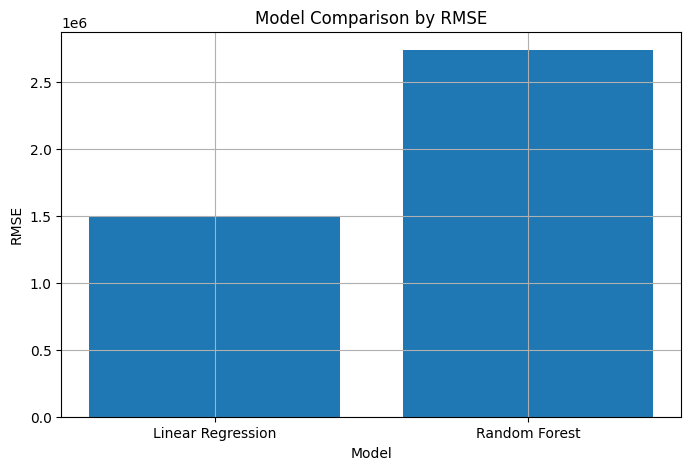

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_m2["Model"], comparison_m2["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

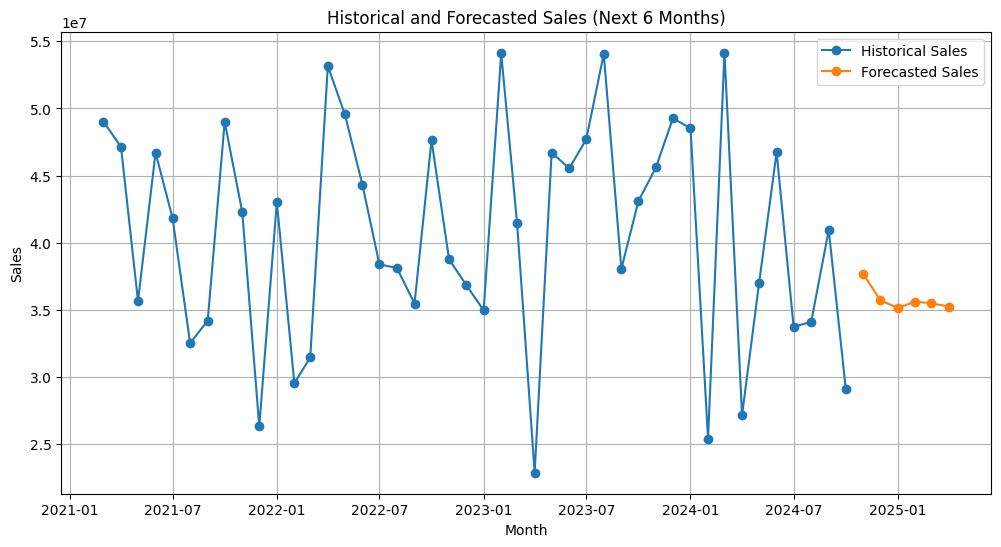

In [ ]:
historical_plot = monthly_sales_refined[["YearMonth", "total_sales"]].copy()
historical_plot["Type"] = "Historical"

forecast_plot = future_forecast_6.copy()
forecast_plot["YearMonth"] = pd.to_datetime(forecast_plot["Month"])
forecast_plot["total_sales"] = forecast_plot["Forecasted_Sales"]
forecast_plot["Type"] = "Forecast"

plt.figure(figsize=(12, 6))
plt.plot(historical_plot["YearMonth"], historical_plot["total_sales"], marker="o", label="Historical Sales")
plt.plot(forecast_plot["YearMonth"], forecast_plot["total_sales"], marker="o", label="Forecasted Sales")
plt.title("Historical and Forecasted Sales (Next 6 Months)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

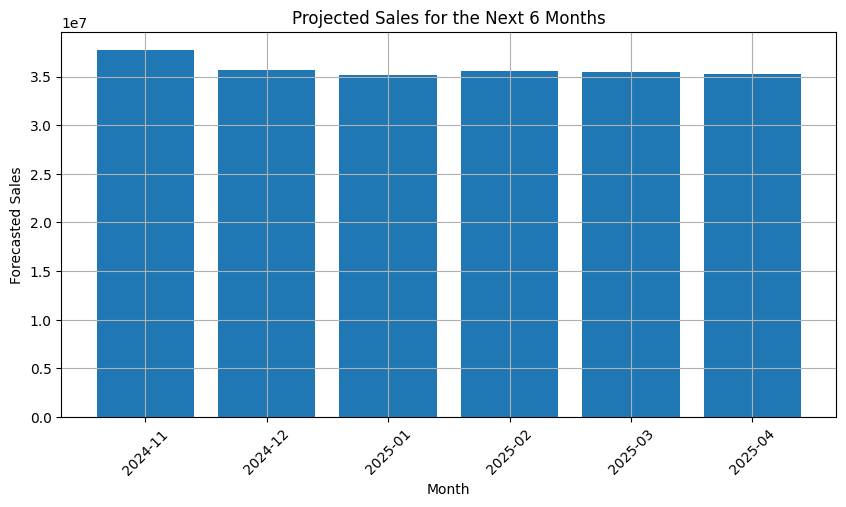

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(future_forecast_6["Month"], future_forecast_6["Forecasted_Sales"])
plt.title("Projected Sales for the Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Milestone 2 Interpretation

The forecasting model was extended to generate six-month sales projections for FinMark. To improve forecasting performance, additional refinements were introduced, including a year feature and a six-month rolling average. These enhancements help the model better capture longer-term trends and seasonal behavior in the data.

Two machine learning models were evaluated again, and their results were compared using MAE and RMSE. The better-performing model was selected to generate the final six-month sales forecast.

The visualizations show both the historical sales trend and the projected sales values for the next six months. These findings can support business planning, inventory decisions, and resource allocation by giving stakeholders a clearer view of future sales expectations.

## Week 8 Interpretation

Monthly sales data was created from historical transactions and enhanced using time-based, lag-based, and rolling average features. Two algorithms were tested: Linear Regression and Random Forest. Their performance was compared using MAE and RMSE, and the better-performing model can be selected for future sales forecasting. This forecasting workflow helps businesses anticipate future demand and support planning and decision-making.